<class 'pandas.core.frame.DataFrame'>
Index: 7050 entries, 246675545449582_1649696485147474 to 1050855161656896_1050858841656528
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_type       7050 non-null   object 
 1   status_published  7050 non-null   object 
 2   num_reactions     7050 non-null   int64  
 3   num_comments      7050 non-null   int64  
 4   num_shares        7050 non-null   int64  
 5   num_likes         7050 non-null   int64  
 6   num_loves         7050 non-null   int64  
 7   num_wows          7050 non-null   int64  
 8   num_hahas         7050 non-null   int64  
 9   num_sads          7050 non-null   int64  
 10  num_angrys        7050 non-null   int64  
 11  Column1           0 non-null      float64
 12  Column2           0 non-null      float64
 13  Column3           0 non-null      float64
 14  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(2)

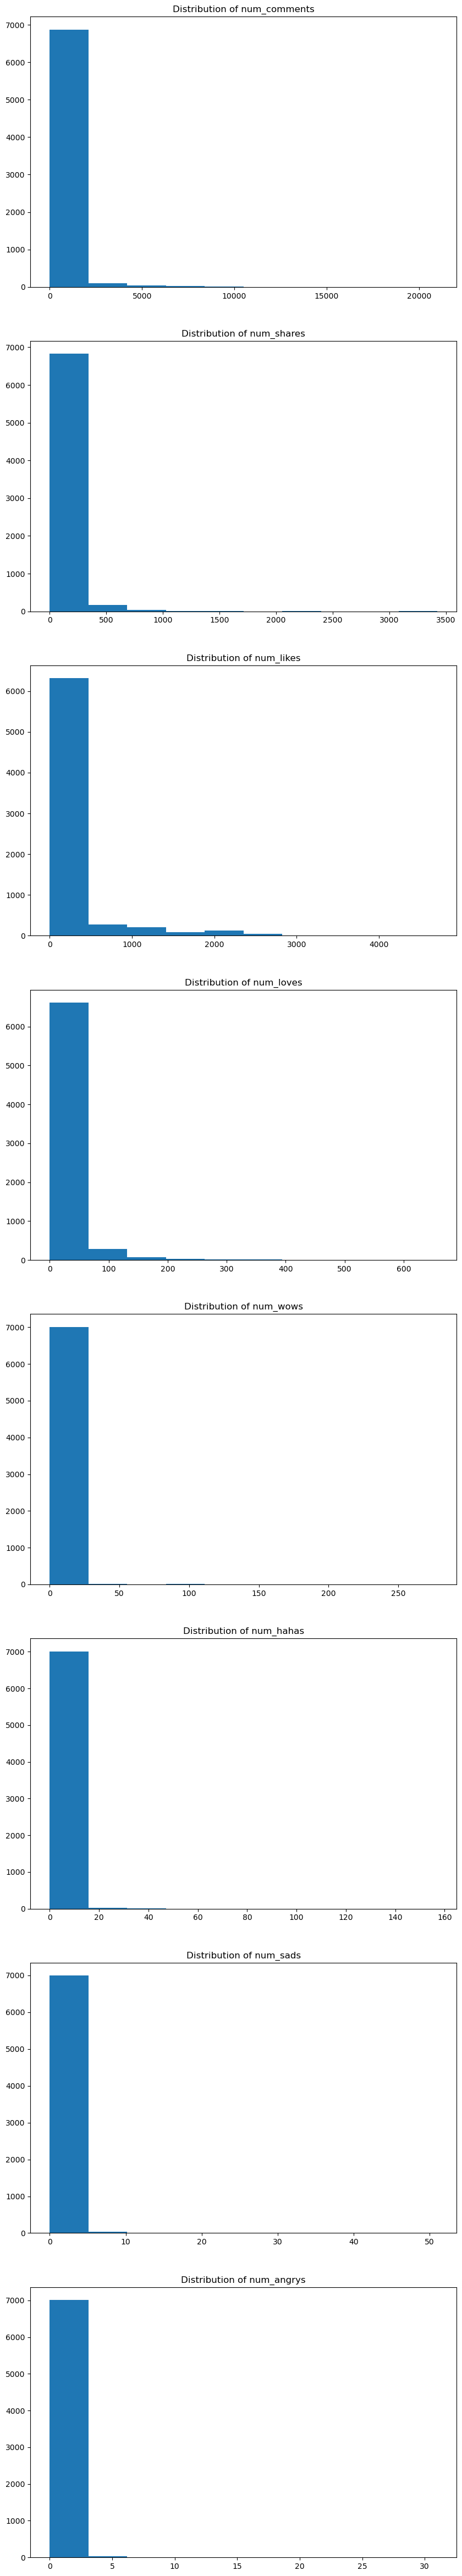

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
data_path = "data/Live.csv"
data = pd.read_csv(data_path, index_col = 0)

# Display basic information about the dataset
print(data.info())
print(data.describe())

data.drop(columns = [f"Column{i}" for i in range(1, 5)] + ["status_published"], inplace = True)

# Visualize the distribution of the first few variables
fig = plt.figure(figsize=(10, 60))
for i, column in enumerate(data.columns[2:]):  # Adjust the range as needed
    ax = fig.add_subplot(len(data.columns[2:]), 1, i+1)
    ax.hist(data.loc[:, column])
    ax.set_title(f'Distribution of {column}')
plt.show()

Feature Scaling: Clustering algorithms are sensitive to the scale of the data. Features with larger scales can dominate the distance calculations. Therefore, it’s essential to normalize or standardize your data to ensure each feature contributes equally.

Handling Missing Data: Missing data can distort the clustering results. Common strategies include imputation (filling in missing values with the mean, median, or a predictive model) or removing incomplete records.

In [17]:
print(data.isna().any())

status_type         False
status_published    False
num_reactions       False
num_comments        False
num_shares          False
num_likes           False
num_loves           False
num_wows            False
num_hahas           False
num_sads            False
num_angrys          False
dtype: bool


In [20]:
data.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
status_id,,,,,,,,,,
246675545449582_1649696485147474,video,529,512,262,432,92,3,1,1,0
246675545449582_1649426988507757,photo,150,0,0,150,0,0,0,0,0
246675545449582_1648730588577397,video,227,236,57,204,21,1,1,0,0
246675545449582_1648576705259452,photo,111,0,0,111,0,0,0,0,0
246675545449582_1645700502213739,photo,213,0,0,204,9,0,0,0,0


In [23]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(data.status_type)
Y_strings = data.loc[:, "status_type"]
Y_encoded = le.transform(Y_strings)
print(Y_encoded)
X = data.drop(columns = ["status_type"])

[3 1 3 ... 1 1 1]


In [25]:
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
# Generate synthetic data
np.random.seed(42)

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# K-means clustering
kmeans = KMeans(n_clusters=3)
kmeans_labels = kmeans.fit_predict(scaled_data)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

kmeans has inertia: Squared sum of the within-cluster distances. The closer to 0, the more compact the clusters are (in comparison to a different kmeans clustering result

In [26]:
kmeans.inertia_ 

38372.99772386958

## ELBOW method to determine optimal cluster number for kmeans

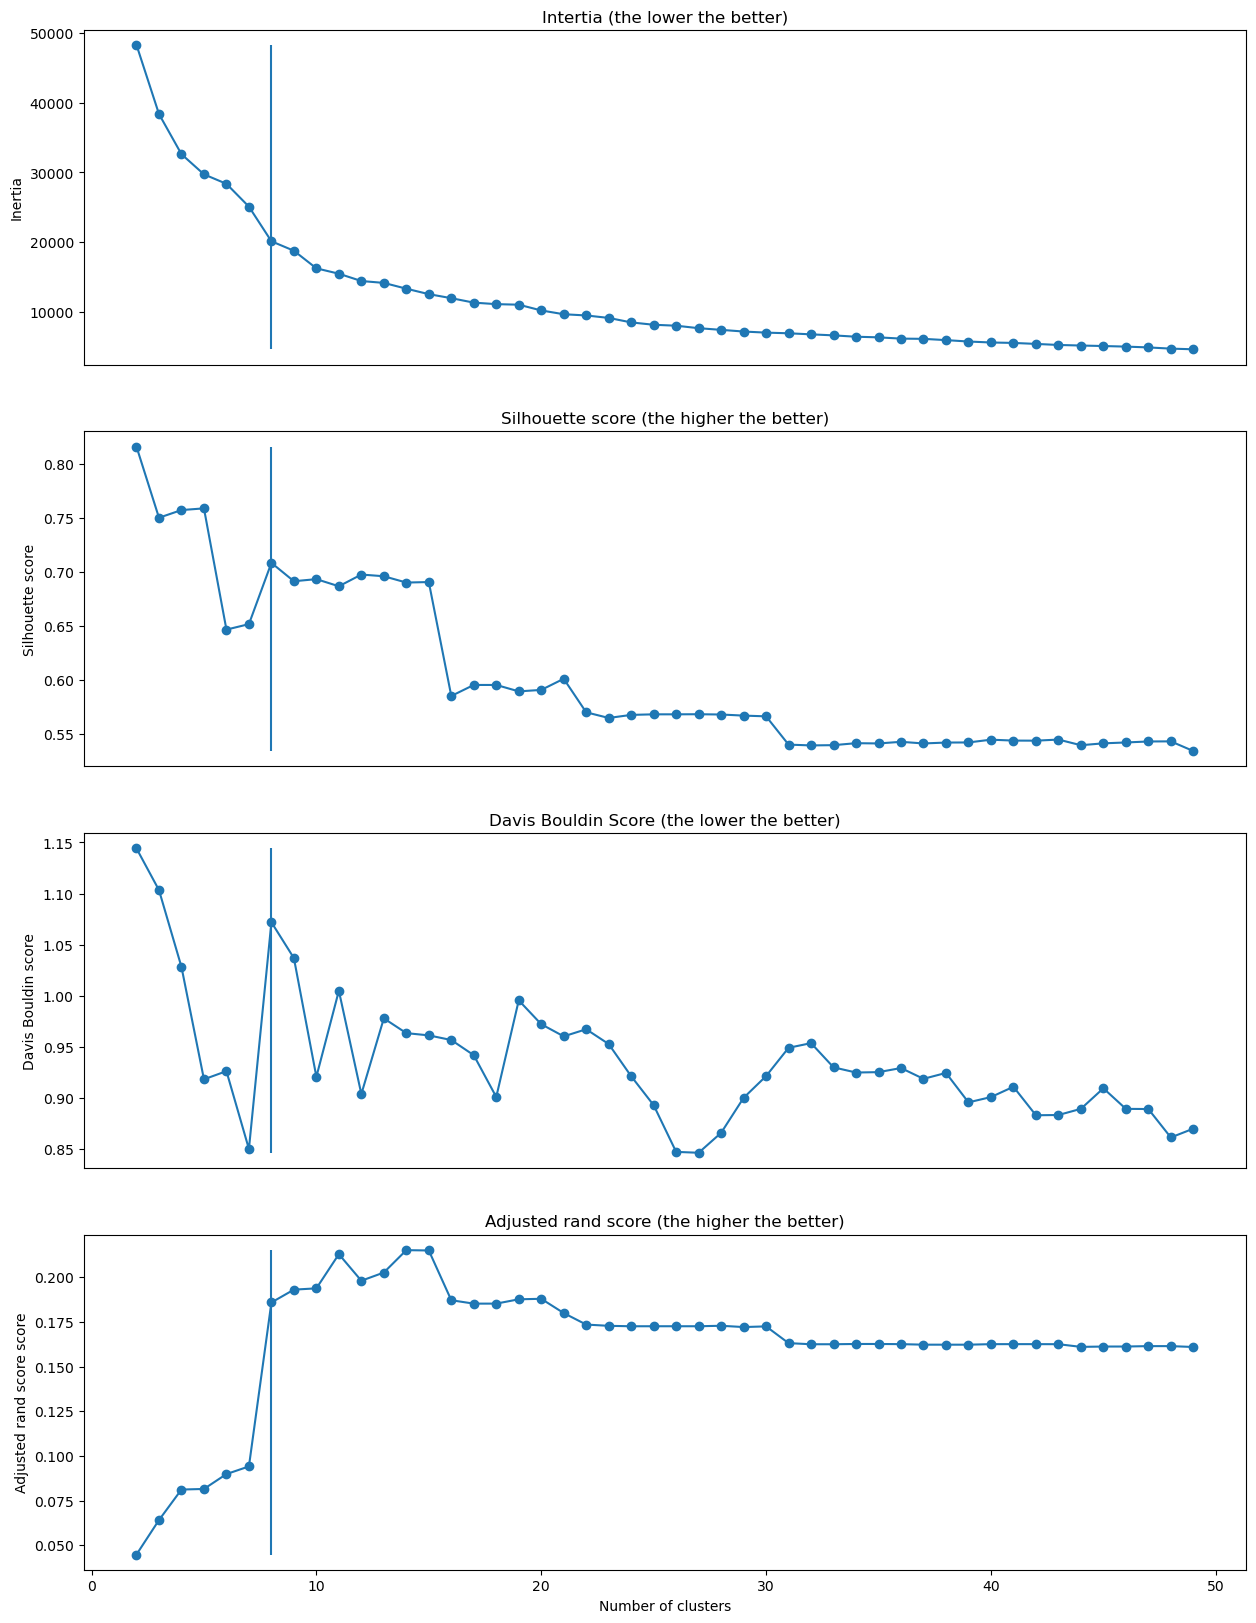

In [44]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
min_clusters = 2
max_clusters = 50
vline = 8

wcss = []
silhouette_scores = []
dbs = []
ars = []
for i in range(min_clusters, max_clusters):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    
    cluster_labels = kmeans.predict(scaled_data)
    silhouette_avg = silhouette_score(scaled_data, cluster_labels)
    dbs_score = davies_bouldin_score(scaled_data, cluster_labels)
    ars_score = adjusted_rand_score(Y_encoded, cluster_labels)

    
    silhouette_scores.append(silhouette_avg)
    wcss.append(kmeans.inertia_)
    dbs.append(dbs_score)
    ars.append(ars_score)

fig = plt.figure(figsize = (15, 20))

ax = fig.add_subplot(411)
ax.plot(list(range(min_clusters, max_clusters)), wcss)
ax.scatter(list(range(min_clusters, max_clusters)), wcss)
ax.vlines(vline, np.min(wcss), np.max(wcss))
ax.axes.get_xaxis().set_visible(False)
ax.set_title("Intertia (the lower the better)")
ax.set_ylabel("Inertia")

ax = fig.add_subplot(412, sharex = ax)
ax.plot(list(range(min_clusters, max_clusters)), silhouette_scores)
ax.scatter(list(range(min_clusters, max_clusters)), silhouette_scores)
ax.vlines(vline, np.min(silhouette_scores), np.max(silhouette_scores))
ax.axes.get_xaxis().set_visible(False)
ax.set_title("Silhouette score (the higher the better)")
ax.set_ylabel("Silhouette score")

ax = fig.add_subplot(413, sharex = ax)
ax.plot(list(range(min_clusters, max_clusters)), dbs)
ax.scatter(list(range(min_clusters, max_clusters)), dbs)
ax.vlines(vline, np.min(dbs), np.max(dbs))
ax.axes.get_xaxis().set_visible(False)
ax.set_title("Davis Bouldin Score (the lower the better)")
ax.set_ylabel("Davis Bouldin score")

ax = fig.add_subplot(414, sharex = ax)
ax.plot(list(range(min_clusters, max_clusters)), ars)
ax.scatter(list(range(min_clusters, max_clusters)), ars)
ax.vlines(vline, np.min(ars), np.max(ars))
ax.set_title("Adjusted rand score (the higher the better)")
ax.set_ylabel("Adjusted rand score score")
ax.set_xlabel("Number of clusters")
plt.show()

Metrics of Internal validation:
1. Silhouette Score: (b-a) / max(a, b) with a being the mean intra-cluster distance and b being the mean nearest-cluster distance
2. Davis Bouldin Score: Average similarty (ratio within-cluster and between-cluster) of most-similar clusters
3. Cohesion / Seperation: How closely realted are items within the same cluster / how distinct are clusterst from each-other

Metrics of External validaiotn:
1. Adjusted Rand Index: Similarity between Clusterings and True Clustering; while adjusting for chance grouping
2. Noramlized Mutual Information: Mutual dependece between clustering results and true clustering
3. Fowlkes-Mallows Index: Compare two different clusterings; are the same pairs of points clusterd in the same clusters?

# How well did DBSCAN perform?

In [59]:
min_eps = 0.5
max_eps = 4.0
min_neigh = 5
max_neigh = 20
# vline = 8

eps_range = np.round(np.arange(min_eps, max_eps, 0.1), 1)
neigh_range = np.arange(min_neigh, max_neigh, 1)

silhouette_scores = np.zeros(shape = (len(eps_range), len(neigh_range)))
dbs = np.zeros(shape = (len(eps_range), len(neigh_range)))
ars = np.zeros(shape = (len(eps_range), len(neigh_range)))

for i, eps in enumerate(eps_range):
    for j, neigh in enumerate(neigh_range):
        dbscan = DBSCAN(eps=eps, min_samples=neigh)
        dbscan_labels = dbscan.fit_predict(scaled_data)

        # No Inertia for DBSCAN
        silhouette_avg = silhouette_score(scaled_data, dbscan_labels)
        dbs_score = davies_bouldin_score(scaled_data, dbscan_labels)
        ars_score = adjusted_rand_score(Y_encoded, dbscan_labels)

        silhouette_scores[i, j] = silhouette_avg
        dbs[i, j] = dbs_score
        ars[i, j] = ars_score

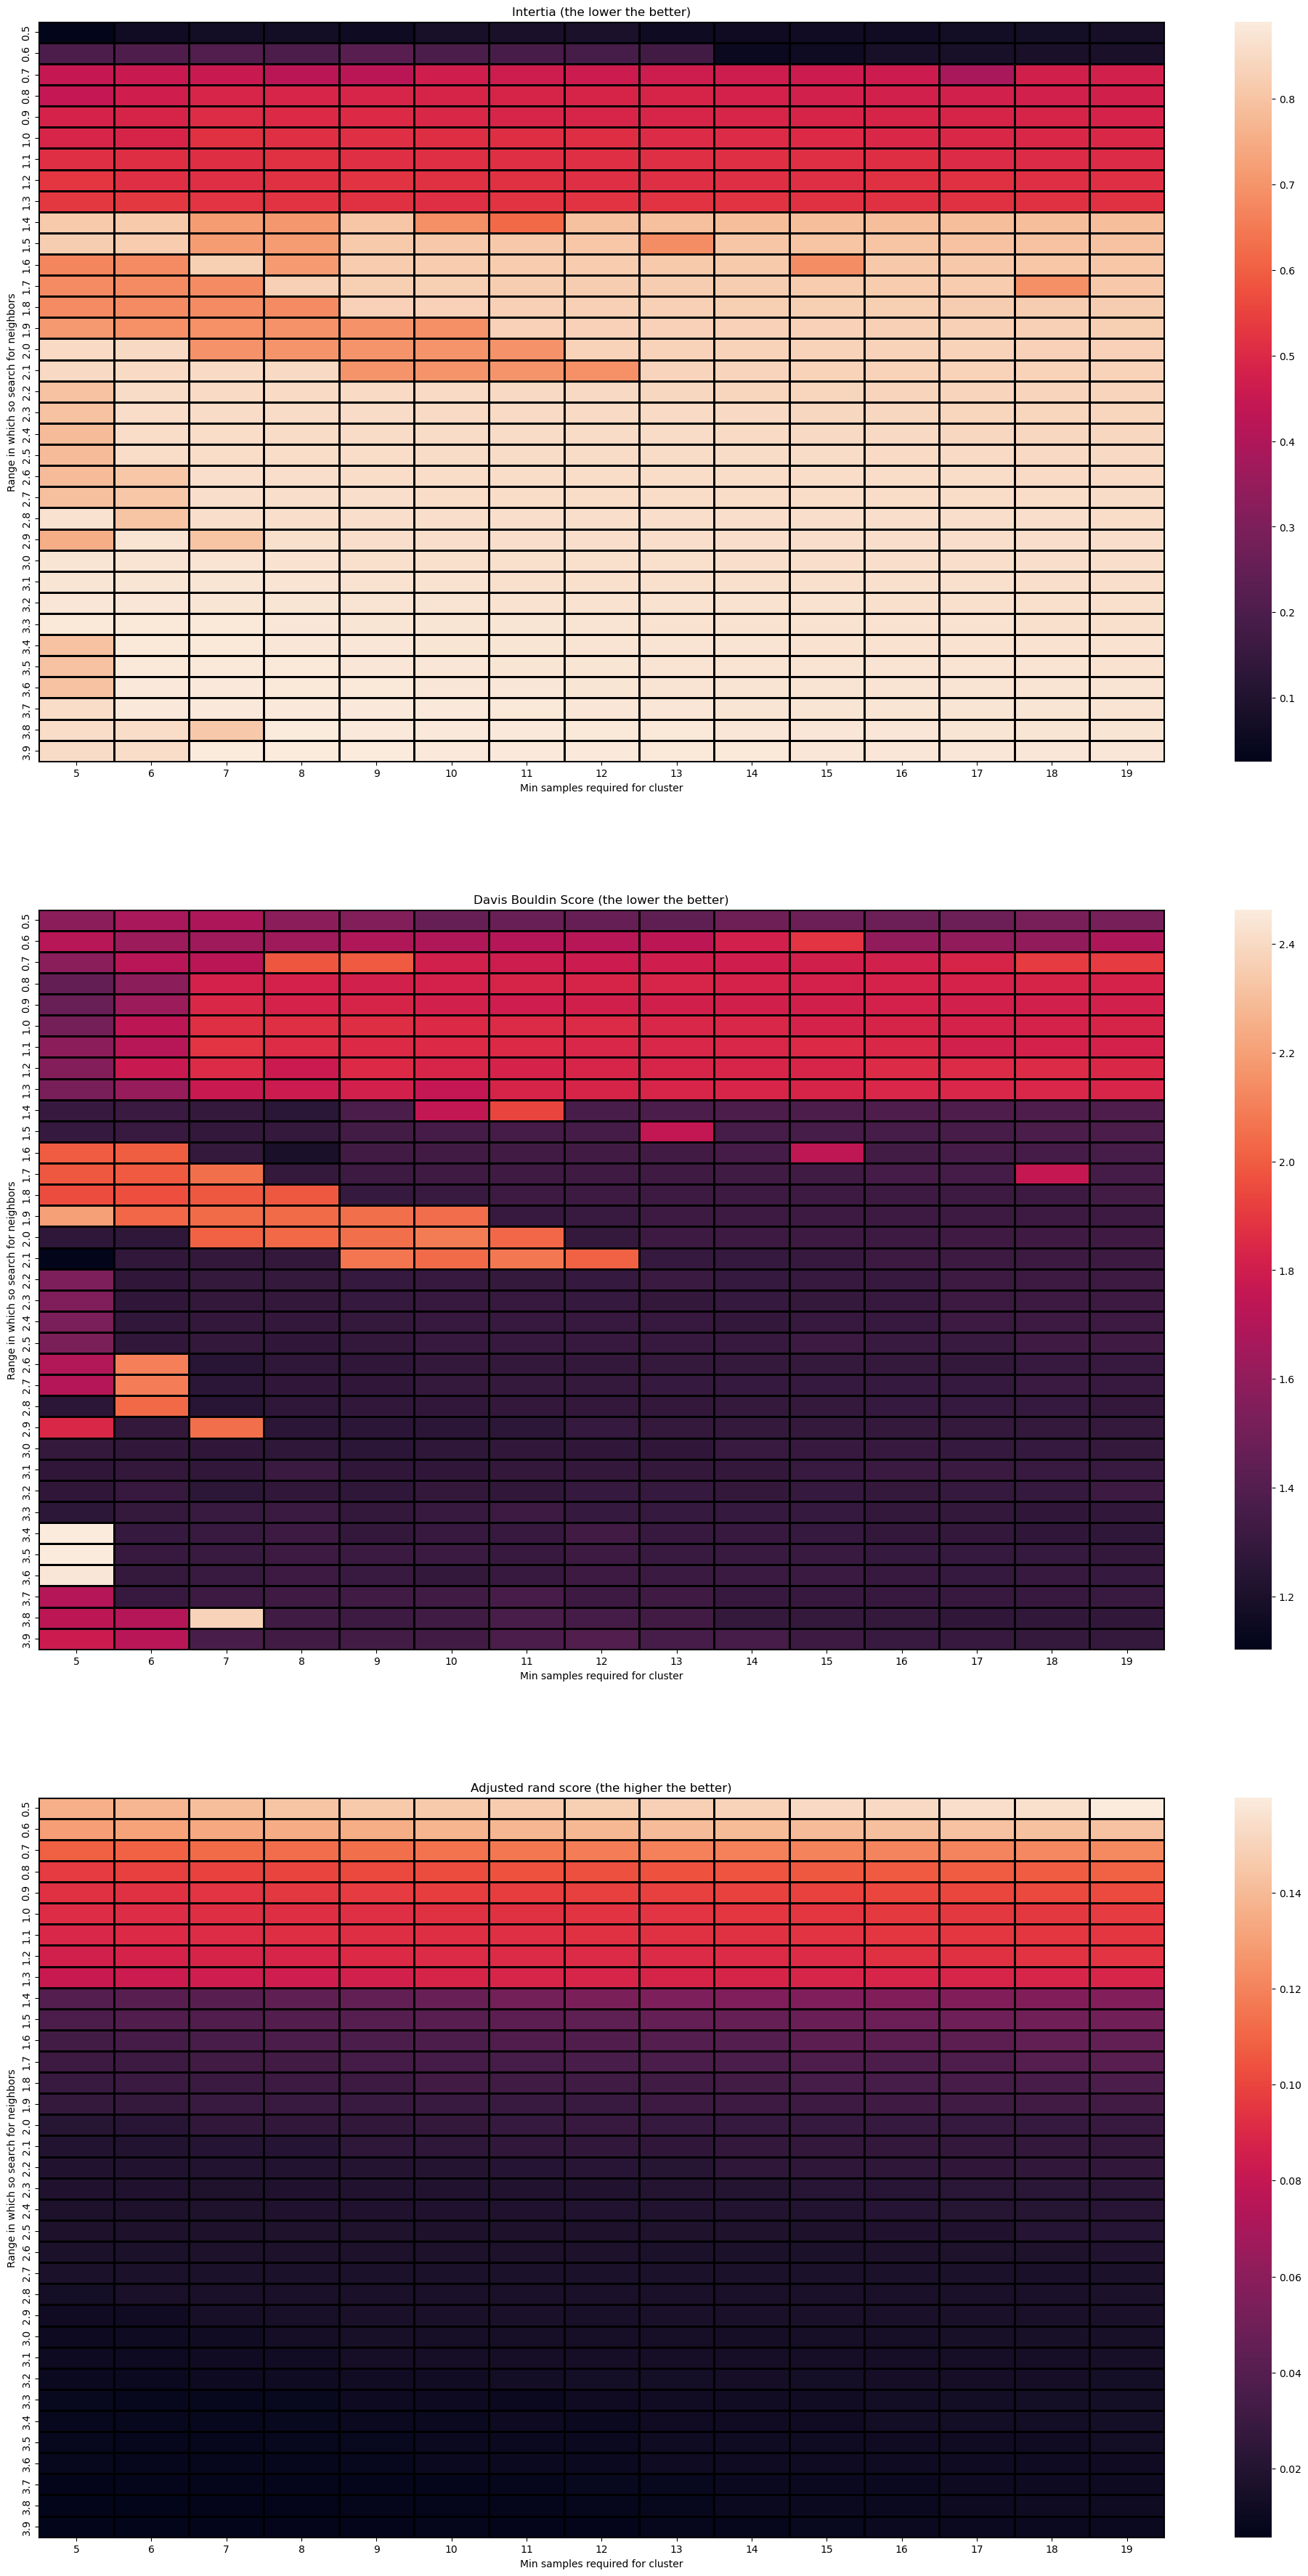

In [65]:
square = False
fig = plt.figure(figsize = (25, 45))

ax = fig.add_subplot(311)
sns.heatmap(silhouette_scores, ax = ax, square = square, linewidths=1, linecolor='black')
for _, spine in ax.spines.items():
    spine.set_visible(True)
ax.set_xticks(np.array([i for i in range(len(neigh_range))]) + 0.5, labels = neigh_range)
ax.set_yticks(np.array([i for i in range(len(eps_range))]) + 0.5, labels = eps_range)
ax.set_ylabel("Range in which so search for neighbors")
ax.set_xlabel("Min samples required for cluster")
ax.set_title("Intertia (the lower the better)")

ax = fig.add_subplot(312)
sns.heatmap(dbs, ax = ax, square = square, linewidths=1, linecolor='black')
for _, spine in ax.spines.items():
    spine.set_visible(True)
ax.set_xticks(np.array([i for i in range(len(neigh_range))]) + 0.5, labels = neigh_range)
ax.set_yticks(np.array([i for i in range(len(eps_range))]) + 0.5, labels = eps_range)
ax.set_title("Davis Bouldin Score (the lower the better)")
ax.set_ylabel("Range in which so search for neighbors")
ax.set_xlabel("Min samples required for cluster")

ax = fig.add_subplot(313)
sns.heatmap(ars, ax = ax, square = square, linewidths=1, linecolor='black')
for _, spine in ax.spines.items():
    spine.set_visible(True)
ax.set_xticks(np.array([i for i in range(len(neigh_range))]) + 0.5, labels = neigh_range)
ax.set_yticks(np.array([i for i in range(len(eps_range))]) + 0.5, labels = eps_range)
ax.set_title("Adjusted rand score (the higher the better)")
ax.set_ylabel("Range in which so search for neighbors")
ax.set_xlabel("Min samples required for cluster")

plt.show()

The min amount of neigthbors has littel effect on the clustering quality, the range in which so search for neightbors is much more important and overall best around 0.5